# Task 1

## 1. Espacio de estados S

La acción anterior no importa, lo que importa es dónde está el dron ahora, porque podemos definir estados por celda dentro de la "ciuddad", como respuesta general pero con otros parámetros para darle contexto.

Pero para los drones no alcanza usar solo una celda. Por ejemplo, si el dron está en `(3, 4)`, no puede decidir bien si no sabe si todavía lleva el paquete, si ya lo entregó o cuánta batería tiene. Dos drones en la misma casilla podrían tener que hacer cosas totalmente distintas.

Entonces proponemos este estado:

`s = (x, y, b, p, d)`

- `(x, y)`: posición del dron en la cuadrícula. Se necesita para saber qué movimientos son posibles y cuánto falta para llegar.
- `b`: batería restante, por ejemplo de 0 a 10. Se necesita porque determina si el dron puede completar el viaje y volver a la base.
- `p`: estado del paquete: `1` si el dron todavía lo lleva y `0` si ya lo entregó. Antes de entregar debe ir al destino; después debe regresar.
- `d`: coordenada del destino asignado. Es necesaria si los pedidos pueden ir a distintas casillas.

La base es siempre la casilla central `(2,2)`, por eso no hace falta guardarla dentro de todos los estados. También suponemos que los edificios o zonas prohibidas son fijos y conocidos: pueden estar definidos una sola vez en el mapa. Omitimos cosas como el nombre del cliente, el color del dron o el número del pedido porque no cambian el resultado del siguiente movimiento.

Estamos omitiendo viento, tráfico de otros drones y estado real de la batería. Es una simplificación. La consecuencia es que el MDP no representa toda la realidad: dos estados que se ven iguales podrían tener riesgos distintos. Aun así, sirve como primer modelo para saber si la idea funciona antes de hacer algo mucho más complejo.

La propiedad de Markov se cumple razonablemente porque, al conocer posición, batería, paquete y destino, podemos decidir la siguiente acción y estimar qué pasará sin necesitar la acción anterior.

## 2. Espacio de acciones A

Las acciones son: `norte`, `sur`, `este`, `oeste`, `entregar` y `esperar`. Son acciones discretas porque el dron escoge una opción de una lista; no puede escoger cualquier dirección decimal, como 37.4 grados.

Hay acciones que se deben restringir:

- No puede ir al norte si ya está en la fila superior, ni salir por ningún borde del tablero.
- No puede ir hacia una casilla con edificio o zona prohibida.
- Solo puede usar `entregar` si está exactamente en el destino y aún tiene el paquete.

Esto se modela con `A(s)`, que significa “las acciones permitidas en el estado s”. Por ejemplo, en una esquina solo habrá dos movimientos válidos. También podríamos dejar que el dron elija una acción inválida, pero entonces lo dejamos en la misma casilla y le damos un castigo; para el laboratorio es más claro simplemente no incluirla en `A(s)`.

## 3. Función de recompensa r(s,a,s')

La recompensa es el puntaje que guía al dron. La empresa quiere entregar rápido, gastar poca batería y no tener accidentes. Como estas metas compiten entre sí, usamos estas recompensas:

- Cada movimiento válido: `-1`. Así evita dar vueltas y hace entregas eficientes.
- Cada unidad de batería usada: `-0.5`. Así prefiere rutas que consuman menos.
- Entregar el paquete: `+30`.
- Volver a la base después de entregar: `+40`.
- Chocar, entrar a una zona prohibida o quedarse sin batería: `-100` y termina la misión.

El castigo de seguridad es el más grande porque un accidente cuesta mucho más que tardar un paso extra. Si el premio por entregar fuera demasiado alto, el agente podría tomar rutas peligrosas. Si el costo de batería fuera demasiado alto, podría evitar hacer entregas largas aunque sean necesarias. Si el castigo por accidente fuera pequeño, podría aprender a arriesgarse demasiado.

## 4. Función de transición p(s' | s,a)

En este ejemplo de tablero básico las transiciones podrían ser deterministas: si voy al este, siempre avanzo una casilla. Para una ciudad real es mejor usar una transición estocástica, o sea, con probabilidades, porque hay viento, errores de GPS, obstáculos temporales o fallos de navegación.

Ejemplos:

1. Si el dron está en `(1,1,7,1,d)` y usa `este`, tiene probabilidad `0.90` de llegar a `(2,1,6,1,d)` y probabilidad `0.10` de quedarse en `(1,1,6,1,d)` por una ráfaga de viento. Casi siempre el vuelo funciona, pero aun cuando no avanza gasta batería tratando de hacerlo, y sería de considerar el viento para el gasto de batería.
2. Si está en `(3,3,5,1,d)` y usa `norte`, tiene probabilidad `0.85` de llegar a `(3,2,4,1,d)`, probabilidad `0.10` de quedarse donde está y probabilidad `0.05` de caer o tener un accidente. La probabilidad pequeña de accidente representa una condición urbana peligrosa.
3. Si está en el destino `(4,4,4,1,(4,4))` y usa `entregar`, cambia a `(4,4,4,0,(4,4))` con probabilidad `0.99`; con probabilidad `0.01` la entrega no se confirma y permanece con el paquete. Es normal que entregar sea muy confiable, pero no perfecto, puede haber alguien que no reciba, o incluso problemas con el paquete en el momento de entrega.

Estos números son supuestos iniciales. Una empresa real debería estimarlos con datos de vuelos y accidentes.

## 5. Factor de descuento gamma

Proponemos `γ = 0.95`. Gamma. En este caso queremos que la entrega y el regreso sean importantes, pero que el dron también prefiera terminarlos pronto. Un valor de 0.95 hace que una ruta segura un poco más larga siga valiendo la pena, sin hacer que el agente pierda demasiado tiempo dando vueltas.


# Task 2

## 1. Casos donde se viola Markov

**Caso 1: el viento.** Dos drones pueden estar en la misma posición, con la misma batería y paquete, pero uno puede tener viento fuerte y el otro viento normal. Si no guardamos el viento, la probabilidad de avanzar o fallar no es igual en ambos casos. Para restaurar Markov agregamos una variable `w` al estado: `w = normal, suave o fuerte`. El costo es que el número de estados se multiplica por tres. Si además guardamos dirección y velocidad del viento, el modelo crece aún más.

**Caso 2: batería desgastada.** Dos drones con batería nivel 5 no necesariamente gastan igual: uno puede tener una batería nueva y otro una dañada. Sin incluir esa condición, el siguiente estado depende de la historia de uso de la batería. Podemos agregar `h`, salud de batería: `buena, media o mala`. El costo vuelve a multiplicar los estados y necesitamos estimar esa salud con sensores.

También podría pasar con otros drones: para saber el riesgo de choque habría que agregar las posiciones y tal vez direcciones de los drones cercanos. Eso haría crecer el espacio de estados muy rápido, porque cada dron adicional puede estar en muchas casillas.

## 2. ¿El dron observa todo el estado?

No es muy razonable asumir que ve el estado completo. El GPS puede tener error; el dron no conoce perfectamente el viento entre edificios; la salud real de la batería es una estimación; y puede no detectar a tiempo aves, cables, obstáculos o drones que estén ocultos.

Un MDP supone que el agente conoce el estado real, por ejemplo que sabe con certeza que está en `(2,3)` y que el viento es suave. Eso hace que el modelo sea más fácil de programar y es aceptable para este laboratorio. En la realidad sería más apropiado un POMDP, que es un MDP parcialmente observable. En un POMDP el dron no ve todo: recibe observaciones imperfectas de GPS, cámara y sensores, y decide usando una estimación de la situación. Es más realista, pero más difícil de resolver.

## 3. ¿Tarea episódica o continua?

Para este problema la modelaría como episódica. Un episodio inicia cuando el dron sale de la base con un paquete y termina cuando lo entrega y regresa a la base, o cuando ocurre un accidente o se queda sin batería. Cada pedido es una misión completa y separada.

Con una tarea episódica tiene sentido dar premios grandes al entregar y al regresar, y usar `γ = 0.95`: queremos completar esta misión pronto y de manera segura.

Si se modelara como continua, el dron nunca termina: al volver toma otro paquete y sigue trabajando. Entonces la recompensa debería incluir beneficios repetidos por entregas y costos constantes por tiempo, batería y riesgo; no dependería solo de un premio final. También convendría un gamma más cercano a 1, por ejemplo `0.99`, porque importan mucho las entregas futuras de toda la jornada.


# Task 3 (Entrega Final)

## Objetivo y alcance

Se implementa desde cero un MDP para una ciudad de drones de `5 × 5` y un evaluador iterativo de políticas. No se utiliza Gymnasium ni ninguna librería de aprendizaje por refuerzo.

Para mantener consistencia con la Tarea 1, el estado conserva la posición y la fase del paquete:

`s = (fila, columna, p)`, donde `p = 1` significa que el dron lleva el paquete y `p = 0` que ya lo entregó y debe regresar.

El destino se fija en `(0, 4)` y la base en `(2, 2)`, por lo que no es necesario repetir `d` en cada estado. La batería se considera suficiente para una misión y su consumo se incorpora en la recompensa de cada vuelo (`-1` por tiempo y `-0.5` por batería). Esta abstracción permite representar los valores de todos los estados espaciales en grids legibles, sin perder las dos fases de entrega y retorno.

El episodio termina cuando el dron vuelve a la base después de entregar. El estado terminal se representa de forma separada y tiene valor cero.


## 1. Parámetros del experimento

El criterio de convergencia es configurable mediante `THETA`. En cada iteración se aplica de manera síncrona el operador de Bellman de expectativa y se termina cuando el cambio máximo entre dos tablas consecutivas es menor que ese umbral.


In [1]:
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


GRID_SIZE = 5
BASE = (2, 2)
DESTINATION = (0, 4)

GAMMA = 0.95
THETA = 1e-8
MAX_ITERATIONS = 20_000

MOVE_SUCCESS_PROBABILITY = 0.90
MOVE_REWARD = -1.5       # -1 por tiempo y -0.5 por batería
WAIT_REWARD = -1.0
DELIVERY_REWARD = 30.0
RETURN_REWARD = 40.0
DELIVERY_SUCCESS_PROBABILITY = 0.99

TERMINAL = "terminal"

print(f"Grid: {GRID_SIZE}x{GRID_SIZE} | base={BASE} | destino={DESTINATION}")
print(f"gamma={GAMMA} | theta={THETA}")


Grid: 5x5 | base=(2, 2) | destino=(0, 4)
gamma=0.95 | theta=1e-08


## 2. MDP completo implementado desde cero

- **Estados:** las 25 posiciones con paquete, las 24 posiciones de retorno (la base ya es terminal en esa fase) y un estado terminal.
- **Acciones:** norte, sur, este, oeste, esperar y entregar. `ENTREGAR` solo está disponible en el destino mientras se lleva el paquete.
- **Transición de vuelo:** con probabilidad `0.90` el movimiento ocurre y con `0.10` el viento deja al dron en la misma celda. Las acciones que salen del grid no pertenecen a `A(s)`.
- **Entrega:** funciona con probabilidad `0.99`; si falla, el dron conserva el paquete.
- **Recompensas:** cada vuelo cuesta `-1.5`, esperar cuesta `-1`, entregar da `+30` y volver a la base después de entregar da `+40`.

El diccionario `P[s][a]` contiene tuplas `(probabilidad, siguiente_estado, recompensa, terminado)`, por lo que especifica conjuntamente la función de transición y la función de recompensa.


In [2]:
class DroneCityMDP:
    # MDP tabular de una misión de entrega y retorno en un GridWorld 5x5.

    MOVEMENT_DELTAS = OrderedDict(
        {
            "NORTE": (-1, 0),
            "SUR": (1, 0),
            "ESTE": (0, 1),
            "OESTE": (0, -1),
        }
    )

    def __init__(
        self,
        grid_size=GRID_SIZE,
        base=BASE,
        destination=DESTINATION,
        move_success_probability=MOVE_SUCCESS_PROBABILITY,
        delivery_success_probability=DELIVERY_SUCCESS_PROBABILITY,
    ):
        self.grid_size = grid_size
        self.base = base
        self.destination = destination
        self.move_success_probability = move_success_probability
        self.delivery_success_probability = delivery_success_probability

        carrying_states = [
            (row, col, 1)
            for row in range(grid_size)
            for col in range(grid_size)
        ]
        returning_states = [
            (row, col, 0)
            for row in range(grid_size)
            for col in range(grid_size)
            if (row, col) != base
        ]

        self.nonterminal_states = carrying_states + returning_states
        self.states = self.nonterminal_states + [TERMINAL]
        self.actions = {
            state: self.available_actions(state) for state in self.states
        }
        self.P = {
            state: {
                action: self.transition_outcomes(state, action)
                for action in self.actions[state]
            }
            for state in self.states
            if state != TERMINAL
        }

    def inside_grid(self, row, col):
        return 0 <= row < self.grid_size and 0 <= col < self.grid_size

    def available_actions(self, state):
        if state == TERMINAL:
            return tuple()

        row, col, package = state
        valid_actions = []
        for action, (delta_row, delta_col) in self.MOVEMENT_DELTAS.items():
            if self.inside_grid(row + delta_row, col + delta_col):
                valid_actions.append(action)

        valid_actions.append("ESPERAR")
        if package == 1 and (row, col) == self.destination:
            valid_actions.append("ENTREGAR")
        return tuple(valid_actions)

    def transition_outcomes(self, state, action):
        if action not in self.actions[state]:
            raise ValueError(f"Acción {action!r} no válida en el estado {state!r}.")

        if action == "ESPERAR":
            return [(1.0, state, WAIT_REWARD, False)]

        if action == "ENTREGAR":
            delivered_state = (*self.destination, 0)
            failure_probability = 1.0 - self.delivery_success_probability
            return [
                (
                    self.delivery_success_probability,
                    delivered_state,
                    DELIVERY_REWARD,
                    False,
                ),
                (failure_probability, state, WAIT_REWARD, False),
            ]

        row, col, package = state
        delta_row, delta_col = self.MOVEMENT_DELTAS[action]
        intended_position = (row + delta_row, col + delta_col)

        returned_to_base = package == 0 and intended_position == self.base
        if returned_to_base:
            success_next_state = TERMINAL
            success_reward = MOVE_REWARD + RETURN_REWARD
            success_done = True
        else:
            success_next_state = (*intended_position, package)
            success_reward = MOVE_REWARD
            success_done = False

        failure_probability = 1.0 - self.move_success_probability
        return [
            (
                self.move_success_probability,
                success_next_state,
                success_reward,
                success_done,
            ),
            (failure_probability, state, MOVE_REWARD, False),
        ]


mdp = DroneCityMDP()

# Verificaciones estructurales del MDP.
assert len(mdp.states) == 50  # 25 con paquete + 24 de retorno + terminal
for state, action_transitions in mdp.P.items():
    for action, outcomes in action_transitions.items():
        probability_sum = sum(probability for probability, *_ in outcomes)
        assert np.isclose(probability_sum, 1.0), (state, action, probability_sum)
        assert all(next_state in mdp.states for _, next_state, _, _ in outcomes)

print(f"Estados totales: {len(mdp.states)}")
print(f"Estados no terminales: {len(mdp.nonterminal_states)}")
print("Todas las distribuciones de transición suman 1.0.")


Estados totales: 50
Estados no terminales: 49
Todas las distribuciones de transición suman 1.0.


## 3. Tres políticas

1. **Uniforme aleatoria:** reparte la probabilidad por igual entre todas las acciones válidas.
2. **Determinista fija:** durante la entrega sigue un recorrido serpenteante predefinido que eventualmente visita el destino; durante el retorno se dirige a la base. No utiliza valores ni aprende.
3. **Greedy mejorada:** se obtiene aplicando una mejora de política de un paso sobre los valores de la política determinista anterior.


In [3]:
def one_hot_policy(valid_actions, selected_action):
    return {
        action: float(action == selected_action)
        for action in valid_actions
    }


def create_uniform_policy(mdp):
    policy = {}
    for state in mdp.nonterminal_states:
        probability = 1.0 / len(mdp.actions[state])
        policy[state] = {
            action: probability for action in mdp.actions[state]
        }
    return policy


def action_between(current_position, next_position):
    delta = (
        next_position[0] - current_position[0],
        next_position[1] - current_position[1],
    )
    for action, action_delta in DroneCityMDP.MOVEMENT_DELTAS.items():
        if action_delta == delta:
            return action
    raise ValueError(f"Las posiciones {current_position} y {next_position} no son adyacentes.")


def create_fixed_deterministic_policy(mdp):
    # Camino serpenteante que cubre el grid y termina en el destino (0, 4).
    snake_path = []
    for row in range(mdp.grid_size - 1, -1, -1):
        columns = (
            range(mdp.grid_size)
            if row % 2 == 0
            else range(mdp.grid_size - 1, -1, -1)
        )
        snake_path.extend((row, col) for col in columns)

    assert snake_path[-1] == mdp.destination
    next_on_snake = {
        snake_path[index]: snake_path[index + 1]
        for index in range(len(snake_path) - 1)
    }

    policy = {}
    for state in mdp.nonterminal_states:
        row, col, package = state
        position = (row, col)

        if package == 1:
            if position == mdp.destination:
                selected_action = "ENTREGAR"
            else:
                selected_action = action_between(position, next_on_snake[position])
        else:
            base_row, base_col = mdp.base
            if col < base_col:
                selected_action = "ESTE"
            elif col > base_col:
                selected_action = "OESTE"
            elif row < base_row:
                selected_action = "SUR"
            else:
                selected_action = "NORTE"

        policy[state] = one_hot_policy(
            mdp.actions[state], selected_action
        )
    return policy


uniform_policy = create_uniform_policy(mdp)
fixed_policy = create_fixed_deterministic_policy(mdp)

for policy in (uniform_policy, fixed_policy):
    for state, probabilities in policy.items():
        assert set(probabilities) == set(mdp.actions[state])
        assert np.isclose(sum(probabilities.values()), 1.0)

print("Políticas uniforme y determinista construidas y validadas.")


Políticas uniforme y determinista construidas y validadas.


## 4. Evaluación iterativa mediante Bellman

Para una política fija `π`, cada actualización síncrona calcula:

`V_{k+1}(s) = Σ_a π(a|s) Σ_{s'} p(s'|s,a)[r(s,a,s') + γV_k(s')]`

El valor terminal se mantiene en cero. La función devuelve la tabla final, el número de iteraciones y el historial del cambio máximo `Δ`.


In [4]:
def evaluate_policy_iteratively(
    mdp,
    policy,
    gamma=GAMMA,
    theta=THETA,
    max_iterations=MAX_ITERATIONS,
):
    if not (0 <= gamma < 1):
        raise ValueError("gamma debe estar en el intervalo [0, 1).")
    if theta <= 0:
        raise ValueError("theta debe ser mayor que cero.")

    values = {state: 0.0 for state in mdp.states}
    delta_history = []

    for iteration in range(1, max_iterations + 1):
        new_values = values.copy()
        maximum_change = 0.0

        for state in mdp.nonterminal_states:
            updated_value = 0.0
            for action, action_probability in policy[state].items():
                if action_probability == 0:
                    continue
                for (
                    transition_probability,
                    next_state,
                    reward,
                    done,
                ) in mdp.P[state][action]:
                    continuation = 0.0 if done else gamma * values[next_state]
                    updated_value += (
                        action_probability
                        * transition_probability
                        * (reward + continuation)
                    )

            new_values[state] = updated_value
            maximum_change = max(
                maximum_change, abs(updated_value - values[state])
            )

        values = new_values
        delta_history.append(maximum_change)
        if maximum_change < theta:
            return values, iteration, delta_history

    raise RuntimeError(
        f"La evaluación no convergió después de {max_iterations} iteraciones."
    )


def action_value(mdp, state, action, values, gamma=GAMMA):
    return sum(
        transition_probability
        * (reward + (0.0 if done else gamma * values[next_state]))
        for transition_probability, next_state, reward, done
        in mdp.P[state][action]
    )


def greedy_policy_from_values(mdp, values, gamma=GAMMA):
    greedy_policy = {}
    for state in mdp.nonterminal_states:
        q_values = {
            action: action_value(mdp, state, action, values, gamma)
            for action in mdp.actions[state]
        }
        best_value = max(q_values.values())
        # Desempate determinista según el orden declarado de las acciones.
        best_action = next(
            action
            for action in mdp.actions[state]
            if np.isclose(q_values[action], best_value)
        )
        greedy_policy[state] = one_hot_policy(
            mdp.actions[state], best_action
        )
    return greedy_policy


uniform_values, uniform_iterations, uniform_deltas = (
    evaluate_policy_iteratively(mdp, uniform_policy)
)
fixed_values, fixed_iterations, fixed_deltas = (
    evaluate_policy_iteratively(mdp, fixed_policy)
)

# La tercera política se deriva explícitamente de V de la política anterior.
greedy_policy = greedy_policy_from_values(mdp, fixed_values)
greedy_values, greedy_iterations, greedy_deltas = (
    evaluate_policy_iteratively(mdp, greedy_policy)
)

results = OrderedDict(
    {
        "Uniforme aleatoria": {
            "policy": uniform_policy,
            "values": uniform_values,
            "iterations": uniform_iterations,
            "deltas": uniform_deltas,
        },
        "Determinista fija": {
            "policy": fixed_policy,
            "values": fixed_values,
            "iterations": fixed_iterations,
            "deltas": fixed_deltas,
        },
        "Greedy sobre V determinista": {
            "policy": greedy_policy,
            "values": greedy_values,
            "iterations": greedy_iterations,
            "deltas": greedy_deltas,
        },
    }
)

print("Las tres políticas convergieron con el mismo criterio theta.")


Las tres políticas convergieron con el mismo criterio theta.


## 5. Tablas de valores y comparación

Cada política produce dos tablas `5 × 5`: la primera contiene todos los estados donde el dron aún lleva el paquete y la segunda los estados de retorno. En la tabla de retorno, la base aparece como `NaN` porque entrar en ella lleva directamente al estado terminal; el valor del estado terminal es `0`.


In [5]:
def value_grid(values, package):
    grid = np.full((mdp.grid_size, mdp.grid_size), np.nan)
    for row in range(mdp.grid_size):
        for col in range(mdp.grid_size):
            state = (row, col, package)
            if state in values:
                grid[row, col] = values[state]
    return pd.DataFrame(
        grid,
        index=[f"fila {row}" for row in range(mdp.grid_size)],
        columns=[f"col {col}" for col in range(mdp.grid_size)],
    )


initial_state = (*BASE, 1)
summary = pd.DataFrame(
    [
        {
            "Política": policy_name,
            "Iteraciones": result["iterations"],
            "Delta final": result["deltas"][-1],
            "V(base, lleva paquete)": result["values"][initial_state],
        }
        for policy_name, result in results.items()
    ]
).set_index("Política")

display(summary.style.format(
    {
        "Delta final": "{:.3e}",
        "V(base, lleva paquete)": "{:.4f}",
    }
))

for policy_name, result in results.items():
    display(Markdown(f"### {policy_name} — {result['iterations']} iteraciones"))
    display(Markdown("**Fase de entrega (`p = 1`)**"))
    display(value_grid(result["values"], package=1).round(3))
    display(Markdown("**Fase de retorno (`p = 0`)**"))
    display(value_grid(result["values"], package=0).round(3))

print(f"V(terminal) = {uniform_values[TERMINAL]:.1f} para todas las políticas.")


,Iteraciones,Delta final,"V(base, lleva paquete)"
Política,,,
Uniforme aleatoria,337,9.645e-09,-24.2360
Determinista fija,50,3.729e-09,13.4983
Greedy sobre V determinista,29,3.521e-09,38.5382


### Uniforme aleatoria — 337 iteraciones

**Fase de entrega (`p = 1`)**

,col 0,col 1,col 2,col 3,col 4
fila 0,-24.515,-23.660,-21.161,-15.565,-2.970
fila 1,-24.992,-24.406,-22.776,-19.772,-15.565
fila 2,-25.467,-25.146,-24.236,-22.776,-21.161
fila 3,-25.789,-25.640,-25.146,-24.406,-23.660
fila 4,-25.860,-25.789,-25.467,-24.992,-24.515


**Fase de retorno (`p = 0`)**

...

**Fase de entrega (`p = 1`)**

,col 0,col 1,col 2,col 3,col 4
fila 0,38.538,42.546,46.789,51.279,56.032
fila 1,34.752,38.538,42.546,46.789,51.279
fila 2,31.174,34.752,38.538,42.546,46.789
fila 3,27.794,31.174,34.752,38.538,42.546
fila 4,24.601,27.794,31.174,34.752,38.538


**Fase de retorno (`p = 0`)**

,col 0,col 1,col 2,col 3,col 4
fila 0,27.443,30.802,34.358,30.802,27.443
fila 1,30.802,34.358,38.122,34.358,30.802
fila 2,34.358,38.122,NaN,38.122,34.358
fila 3,30.802,34.358,38.122,34.358,30.802
fila 4,27.443,30.802,34.358,30.802,27.443


V(terminal) = 0.0 para todas las políticas.


## 6. Visualización del GridWorld

Los seis mapas usan la misma escala de color para que la comparación sea directa. En cada celda se muestra el valor y se superpone la acción greedy respecto de la tabla evaluada: `↑`, `↓`, `→`, `←`, `•` para esperar y `✓` para entregar.


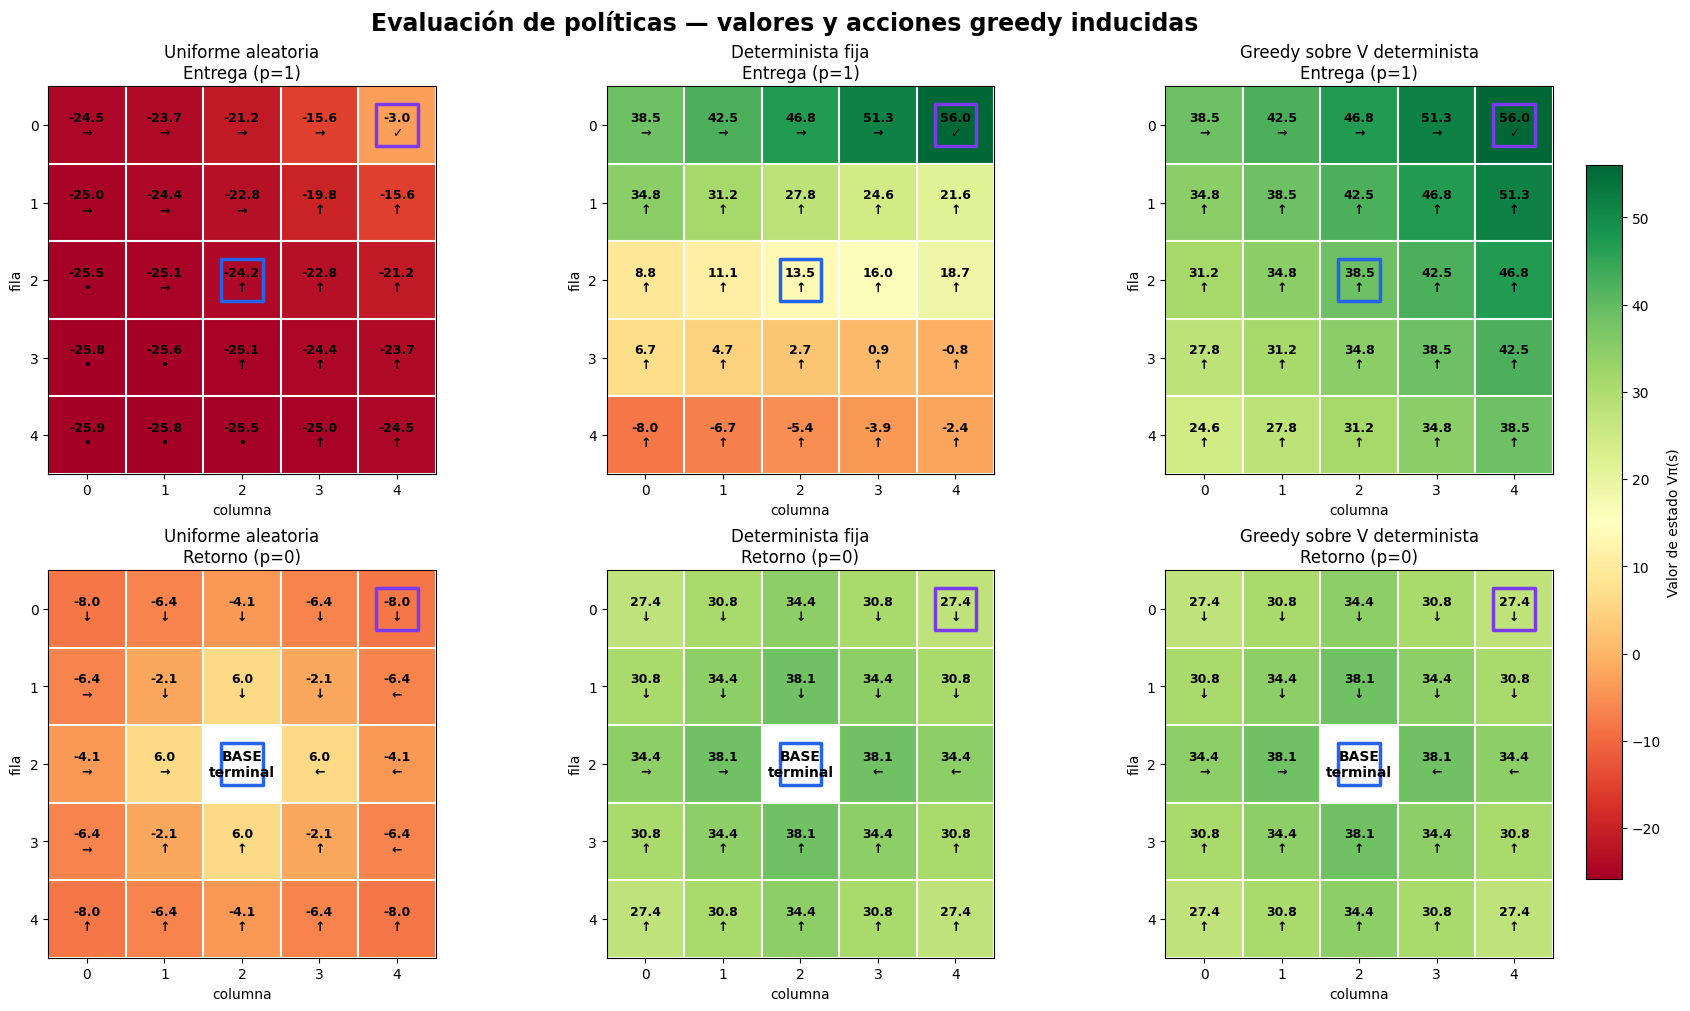

In [6]:
ACTION_SYMBOLS = {
    "NORTE": "↑",
    "SUR": "↓",
    "ESTE": "→",
    "OESTE": "←",
    "ESPERAR": "•",
    "ENTREGAR": "✓",
}


def selected_action(policy, state):
    return max(policy[state], key=policy[state].get)


# Para cada V mostramos la política greedy que inducen esos valores.
greedy_overlays = {
    policy_name: greedy_policy_from_values(mdp, result["values"])
    for policy_name, result in results.items()
}

all_nonterminal_values = [
    result["values"][state]
    for result in results.values()
    for state in mdp.nonterminal_states
]
color_min, color_max = min(all_nonterminal_values), max(all_nonterminal_values)

fig, axes = plt.subplots(
    2,
    len(results),
    figsize=(18, 10),
    constrained_layout=True,
)

for column, (policy_name, result) in enumerate(results.items()):
    overlay_policy = greedy_overlays[policy_name]
    for row_index, package in enumerate((1, 0)):
        axis = axes[row_index, column]
        grid = value_grid(result["values"], package).to_numpy()
        masked_grid = np.ma.masked_invalid(grid)
        image = axis.imshow(
            masked_grid,
            cmap="RdYlGn",
            vmin=color_min,
            vmax=color_max,
        )

        for row in range(mdp.grid_size):
            for col in range(mdp.grid_size):
                state = (row, col, package)
                if state not in mdp.nonterminal_states:
                    axis.text(
                        col,
                        row,
                        "BASE\nterminal",
                        ha="center",
                        va="center",
                        fontsize=10,
                        fontweight="bold",
                    )
                    continue

                action = selected_action(overlay_policy, state)
                axis.text(
                    col,
                    row,
                    f"{result['values'][state]:.1f}\n{ACTION_SYMBOLS[action]}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="semibold",
                )

        # Marcas de contexto de la ciudad.
        axis.scatter(
            [mdp.base[1]],
            [mdp.base[0]],
            marker="s",
            s=900,
            facecolors="none",
            edgecolors="#2563eb",
            linewidths=2.5,
        )
        axis.scatter(
            [mdp.destination[1]],
            [mdp.destination[0]],
            marker="s",
            s=900,
            facecolors="none",
            edgecolors="#7c3aed",
            linewidths=2.5,
        )

        phase_name = "Entrega (p=1)" if package == 1 else "Retorno (p=0)"
        axis.set_title(f"{policy_name}\n{phase_name}", fontsize=12)
        axis.set_xticks(range(mdp.grid_size), labels=range(mdp.grid_size))
        axis.set_yticks(range(mdp.grid_size), labels=range(mdp.grid_size))
        axis.set_xlabel("columna")
        axis.set_ylabel("fila")
        axis.set_xticks(np.arange(-0.5, mdp.grid_size, 1), minor=True)
        axis.set_yticks(np.arange(-0.5, mdp.grid_size, 1), minor=True)
        axis.grid(which="minor", color="white", linewidth=1.5)
        axis.tick_params(which="minor", bottom=False, left=False)

colorbar = fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.82, pad=0.02)
colorbar.set_label("Valor de estado Vπ(s)")
fig.suptitle(
    "Evaluación de políticas — valores y acciones greedy inducidas",
    fontsize=17,
    fontweight="bold",
)
plt.show()


## 7. Comprobaciones y conclusión

Además de verificar las probabilidades del MDP, se comprueba que las tres evaluaciones cumplen el umbral solicitado y que la mejora greedy no reduce el valor del estado inicial frente a la política determinista de la que fue derivada.


In [7]:
for policy_name, result in results.items():
    assert result["deltas"][-1] < THETA

greedy_improvement = (
    greedy_values[initial_state] - fixed_values[initial_state]
)
assert greedy_improvement >= -1e-8

best_policy_name = summary["V(base, lleva paquete)"].idxmax()
display(
    Markdown(
        f"**Resultado principal.** Desde el estado inicial `{initial_state}`, "
        f"la política greedy mejora el valor de la determinista fija en "
        f"**{greedy_improvement:.4f}** unidades. Entre las tres políticas "
        f"evaluadas, el mayor valor inicial corresponde a **{best_policy_name}**. "
        f"Todas convergieron con `Δ < {THETA}`."
    )
)


**Resultado principal.** Desde el estado inicial `(2, 2, 1)`, la política greedy mejora el valor de la determinista fija en **25.0398** unidades. Entre las tres políticas evaluadas, el mayor valor inicial corresponde a **Greedy sobre V determinista**. Todas convergieron con `Δ < 1e-08`.